## Regression Model predicting High/Medium/Low with output into 'stress_predictions.csv'

In [1]:
from load_stress_data import stress_level_v1, stress_level_v2, df_features

Loading stress data...
Loaded 196 segments from 22 subjects



IMPROVED STRESS REGRESSION (GROUP-SAFE)

[1] Reshaping stress labels (V1 + V2) ...
Male labels:   144
Female labels: 126
Total labels:  270
Tasks in labels: ['Baseline', 'First Rest', 'Opposite Opinion', 'Real Opinion', 'Second Rest', 'Stroop', 'Subtract', 'TMCT']

[2] Normalizing df_features keys ...

[3] Merging df_features + stress labels ...
    subject   label              task  duration      SDNN     RMSSD  \
0       S05    REST          Baseline       478  0.073019  0.047788   
1       S05  STRESS            Stroop       112  0.049038  0.039729   
2       S05    REST        First Rest       336  0.066626  0.051433   
3       S05  STRESS              TMCT       169  0.075088  0.031882   
4       S05    REST       Second Rest       227  0.069203  0.053553   
..      ...     ...               ...       ...       ...       ...   
159     P06    REST        First Rest       853  0.069613  0.048003   
160     P06  STRESS      Real Opinion        41       NaN       NaN   
161     P06 

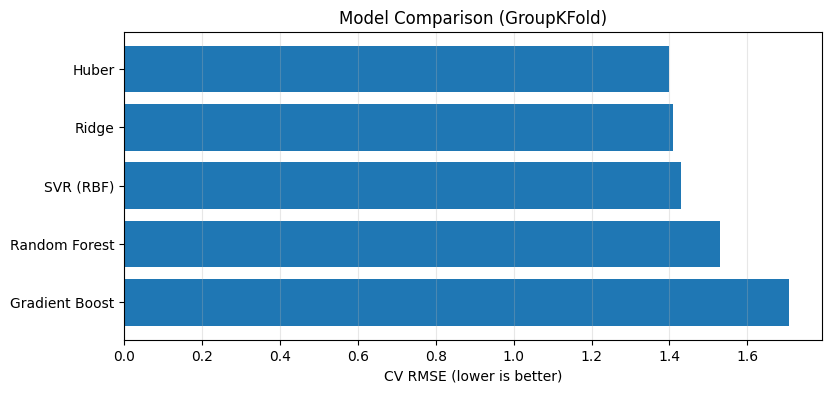

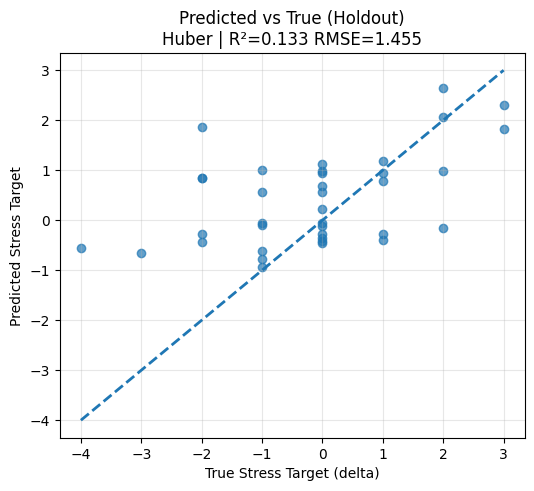

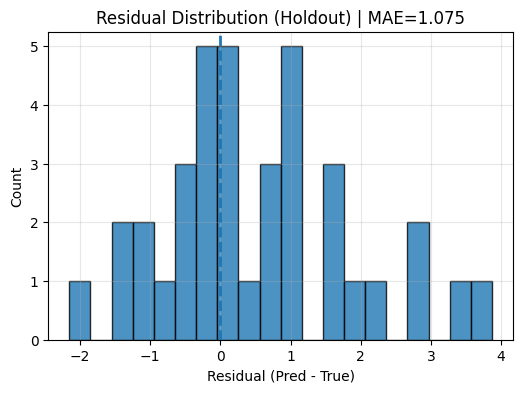


[8] Feature importance (if supported)...

Top coefficients (|coef|):
task_TMCT                0.694103
task_Second Rest         0.321546
task_Real Opinion        0.236153
HR_mean                  0.234357
ACC_mean                 0.218747
SDNN                     0.214916
task_First Rest          0.183449
HR_std                   0.164881
HR_max                   0.144390
task_Subtract            0.124893
task_Baseline            0.076697
task_Stroop              0.017203
task_Opposite Opinion    0.013424
dtype: float64


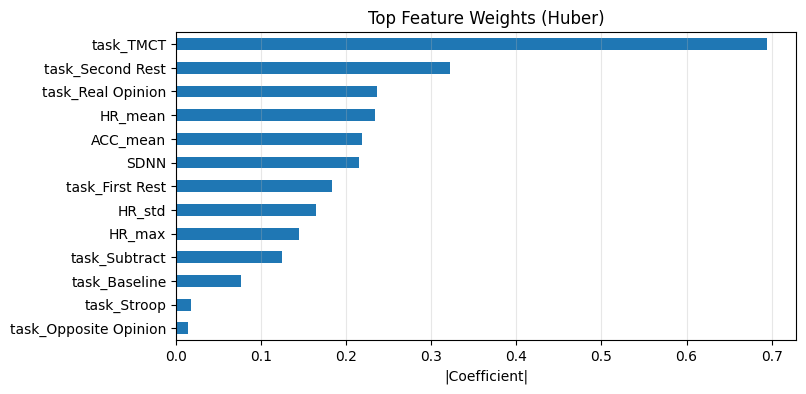


✓ DONE


In [2]:
# ================================================================
# IMPROVED STRESS REGRESSION (NUMERIC STRESS SCORE / DELTA STRESS)
# V1 labels for males, V2 labels for females
# Uses existing df_features (preprocessed)
# Fixes female ID mismatch (f01 -> P01), normalizes task strings
# Adds TASK one-hot (big boost)
# Optionally predicts subject-relative stress (delta from baseline) (big boost)
# Optionally within-subject z-score of physiology features (reduces subject bias)
# Uses TRUE group CV (GroupKFold) to avoid subject leakage
# Prints: CV R²/RMSE/MAE + Holdout R²/RMSE/MAE + plots
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge

print("\n" + "="*80)
print("IMPROVED STRESS REGRESSION (GROUP-SAFE)")
print("="*80)

# -----------------------------
# CHOICES (toggle these)
# -----------------------------
USE_TASK_ONEHOT = True               # strongly recommended
USE_GENDER_ONEHOT = False            # optional
PREDICT_DELTA_FROM_BASELINE = True   # recommended (often improves R²)
WITHIN_SUBJECT_ZSCORE = True         # recommended with delta target
MIN_DURATION_SEC = None              # e.g., 30 or 60 if you have 'duration' col
MAX_ROW_MISSING_FRAC = 0.30          # drop rows with >30% missing phys features

# ----------------------------------------------------------------
# 0) NORMALIZATION HELPERS (KEY CLEANING)
# ----------------------------------------------------------------
def norm_subject(s):
    """
    Normalize subject IDs so merges work:
      - 'f01' -> 'P01'
      - 'p1'  -> 'P01'
      - 'S4'  -> 'S04'
    """
    s = str(s).strip()
    if len(s) == 0:
        return s
    low = s.lower()

    if low.startswith("f"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("p"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("s"):
        num = low[1:]
        return "S" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    return s

def norm_task(t):
    """Strip + collapse whitespace so task strings match across sources."""
    return " ".join(str(t).strip().split())

TASK_MAP = {
    # Add mappings only if you discover naming drift:
    # "Transition Rest 1": "Transition Rest",
    # "Transition Rest 2": "Transition Rest",
}
def map_task(t):
    t = norm_task(t)
    return TASK_MAP.get(t, t)

# ----------------------------------------------------------------
# 1) RESHAPE STRESS LABELS (V1 male + V2 female)
#    Requires: stress_level_v1, stress_level_v2 already loaded as DataFrames
# ----------------------------------------------------------------
print("\n[1] Reshaping stress labels (V1 + V2) ...")

stress_male = (
    stress_level_v1.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_male["subject"] = stress_male["subject"].apply(norm_subject)
stress_male["task"] = stress_male["task"].apply(map_task)
stress_male["stress_score"] = pd.to_numeric(stress_male["stress_score"], errors="coerce")
stress_male = stress_male.dropna()

stress_female = (
    stress_level_v2.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_female["subject"] = stress_female["subject"].apply(norm_subject)
stress_female["task"] = stress_female["task"].apply(map_task)
stress_female["stress_score"] = pd.to_numeric(stress_female["stress_score"], errors="coerce")
stress_female = stress_female.dropna()

stress_all = pd.concat([stress_male, stress_female], ignore_index=True)

print(f"Male labels:   {len(stress_male)}")
print(f"Female labels: {len(stress_female)}")
print(f"Total labels:  {len(stress_all)}")
print("Tasks in labels:", sorted(stress_all["task"].unique()))

# ----------------------------------------------------------------
# 2) PREP df_features (normalize merge keys)
# ----------------------------------------------------------------
print("\n[2] Normalizing df_features keys ...")

df_features = df_features.copy()
df_features["subject"] = df_features["subject"].apply(norm_subject)
df_features["task"] = df_features["task"].apply(map_task)

# ----------------------------------------------------------------
# 3) MERGE FEATURES + LABELS
# ----------------------------------------------------------------
print("\n[3] Merging df_features + stress labels ...")

data = df_features.merge(
    stress_all[["subject", "task", "stress_score"]],
    on=["subject", "task"],
    how="inner"
)
print(data)

if len(data) == 0:
    raise ValueError("❌ Merge produced 0 rows. Check subject/task normalization and TASK_MAP.")

print(f"✓ Merged samples: {len(data)}")
print(f"✓ Subjects: {data['subject'].nunique()}")
if "gender" in data.columns:
    print("Merged gender counts:\n", data["gender"].value_counts())

print(f"Stress range: {data['stress_score'].min():.1f} - {data['stress_score'].max():.1f}")
print(f"Stress mean±std: {data['stress_score'].mean():.2f} ± {data['stress_score'].std():.2f}")

# ----------------------------------------------------------------
# 3.5) OPTIONAL FILTERS (duration + missingness)
# ----------------------------------------------------------------
# Duration filter (if you have a 'duration' column)
if MIN_DURATION_SEC is not None and "duration" in data.columns:
    before = len(data)
    data = data[data["duration"] >= MIN_DURATION_SEC].copy()
    print(f"\n[Filter] duration >= {MIN_DURATION_SEC}s: {before} -> {len(data)}")

# ----------------------------------------------------------------
# 4) FEATURE SETUP (base physiological features)
# ----------------------------------------------------------------
print("\n[4] Preparing features ...")

base_feature_cols = [
    "SDNN", 
    "HR_mean", "HR_std", "HR_max",
    "ACC_mean"
]

# keep cols that exist + not mostly missing
base_feature_cols = [c for c in base_feature_cols if c in data.columns and data[c].notna().mean() > 0.5]
if len(base_feature_cols) == 0:
    raise ValueError("❌ No usable base physiological features found in `data`.")

# coerce numeric
data[base_feature_cols] = data[base_feature_cols].apply(pd.to_numeric, errors="coerce")

# Row missingness filter on phys columns
row_missing = data[base_feature_cols].isna().mean(axis=1)
before = len(data)
data = data[row_missing <= MAX_ROW_MISSING_FRAC].copy()
print(f"[Filter] phys missingness <= {MAX_ROW_MISSING_FRAC:.0%}: {before} -> {len(data)}")

# ----------------------------------------------------------------
# 4.5) ADD TASK/GENDER ONE-HOT FEATURES (big boost)
# ----------------------------------------------------------------
dummy_cols = []

if USE_TASK_ONEHOT:
    task_dummies = pd.get_dummies(data["task"], prefix="task")
    data = pd.concat([data, task_dummies], axis=1)
    dummy_cols += task_dummies.columns.tolist()

if USE_GENDER_ONEHOT and "gender" in data.columns:
    gender_dummies = pd.get_dummies(data["gender"], prefix="gender")
    data = pd.concat([data, gender_dummies], axis=1)
    dummy_cols += gender_dummies.columns.tolist()

# ----------------------------------------------------------------
# 4.6) TARGET ENGINEERING (delta from baseline) (big boost)
# ----------------------------------------------------------------
if PREDICT_DELTA_FROM_BASELINE:
    # baseline stress per subject (from Baseline task rows)
    baseline_map = (
        data.loc[data["task"] == "Baseline", ["subject", "stress_score"]]
        .groupby("subject")["stress_score"]
        .mean()
    )

    data["baseline_stress"] = data["subject"].map(baseline_map)

    before = len(data)
    data = data.dropna(subset=["baseline_stress"]).copy()
    print(f"[Target] drop missing baseline: {before} -> {len(data)}")

    data["stress_target"] = data["stress_score"] - data["baseline_stress"]
    print("[Target] Using stress_delta = stress_score - baseline_stress")
else:
    data["stress_target"] = data["stress_score"]
    print("[Target] Using absolute stress_score")

# ----------------------------------------------------------------
# 4.7) WITHIN-SUBJECT Z-SCORE ON PHYS FEATURES (reduces subject bias)
# ----------------------------------------------------------------
if WITHIN_SUBJECT_ZSCORE:
    def zscore(x):
        return (x - x.mean()) / (x.std(ddof=0) + 1e-8)
    data[base_feature_cols] = data.groupby("subject")[base_feature_cols].transform(zscore)
    print("[Features] Applied within-subject z-score to physiology features")

# Final feature set
feature_cols = base_feature_cols + dummy_cols

print(f"✓ Base phys features: {len(base_feature_cols)}")
print(f"✓ Dummy features:     {len(dummy_cols)}")
print(f"✓ Total features:     {len(feature_cols)}")
print("Feature cols (sample):", feature_cols[:10], "..." if len(feature_cols) > 10 else "")

# Build X, y, groups
X = data[feature_cols].apply(pd.to_numeric, errors="coerce").values
y = pd.to_numeric(data["stress_target"], errors="coerce").values
groups = data["subject"].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique subjects: {pd.Series(groups).nunique()}")
print("Target stats:\n", pd.Series(y).describe())

# ----------------------------------------------------------------
# 5) MODELS + GROUP CV (R² / RMSE / MAE)
# ----------------------------------------------------------------
print("\n[5] Training regression models (GroupKFold)...")

models = {
    "Ridge": Ridge(alpha=1.0),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001),
    "Random Forest": RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42),
    "Gradient Boost": GradientBoostingRegressor(n_estimators=500, max_depth=3, random_state=42),
    "SVR (RBF)": SVR(kernel="rbf")
}

cv = GroupKFold(n_splits=5)

results = []
print("\n5-Fold Group CV:")
print("-" * 100)

for name, model in models.items():
    pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        model
    )

    r2 = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="r2")
    neg_mse = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_squared_error")
    neg_mae = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")

    rmse = float(np.sqrt(-neg_mse.mean()))
    mae = float(-neg_mae.mean())

    results.append({
        "Model": name,
        "CV R2": float(r2.mean()),
        "CV R2 Std": float(r2.std()),
        "CV RMSE": rmse,
        "CV MAE": mae
    })

    print(f"{name:16}: R²={r2.mean():7.3f} (±{r2.std():.3f}) | RMSE={rmse:.3f} | MAE={mae:.3f}")

df_results = pd.DataFrame(results).sort_values("CV RMSE", ascending=True).reset_index(drop=True)

best_name = df_results.loc[0, "Model"]
best_model = models[best_name]
print(f"\n✓ Best by lowest CV RMSE: {best_name}")

# ----------------------------------------------------------------
# 6) GROUP HOLDOUT EVALUATION
# ----------------------------------------------------------------
print("\n[6] Holdout evaluation (GroupShuffleSplit)...")

splitter = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

best_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    best_model
)

best_pipe.fit(X[train_idx], y[train_idx])
y_pred = best_pipe.predict(X[test_idx])

test_r2 = r2_score(y[test_idx], y_pred)
test_rmse = float(np.sqrt(mean_squared_error(y[test_idx], y_pred)))
test_mae = float(mean_absolute_error(y[test_idx], y_pred))

print("\nHoldout metrics:")
print(f"  R²:   {test_r2:.3f}")
print(f"  RMSE: {test_rmse:.3f}")
print(f"  MAE:  {test_mae:.3f}")
print("  Holdout subjects:", sorted(pd.Series(groups[test_idx]).unique()))


# ----------------------------------------------------------------
# 6.5) POST-HOC: MAP REGRESSION OUTPUTS TO Low/Medium/High (INTERPRETATION ONLY)
# ----------------------------------------------------------------
print("\n[6.5] Post-hoc mapping to Low/Medium/High (interpretation only) ...")

# If you are predicting DELTA FROM BASELINE, you must bin DELTA, not absolute stress.
# These thresholds are reasonable starting points; tweak if your delta distribution is different.
def delta_to_level(d):
    if d <= -1:
        return "Low"
    elif d <= 1:
        return "Medium"
    else:
        return "High"

# If you are predicting ABSOLUTE stress_score, bin on the original scale (your earlier choice).
def stress_to_level_abs(s):
    if s <= 3:
        return "Low"
    elif s <= 6:
        return "Medium"
    else:
        return "High"

if PREDICT_DELTA_FROM_BASELINE:
    y_true_level = pd.Series(y[test_idx]).apply(delta_to_level)
    y_pred_level = pd.Series(y_pred).apply(delta_to_level)
    print("Using DELTA bins: Low<=-1, Medium<=1, High>1")
else:
    y_true_level = pd.Series(y[test_idx]).apply(stress_to_level_abs)
    y_pred_level = pd.Series(y_pred).apply(stress_to_level_abs)
    print("Using ABS bins: Low<=3, Medium<=6, High>6")

print("\nTrue levels (holdout):")
print(y_true_level.value_counts())

print("\nPredicted levels (holdout):")
print(y_pred_level.value_counts())

print("\nSample (first 15 holdout predictions):")
preview = pd.DataFrame({
    "subject": pd.Series(groups[test_idx]),
    "task": data.iloc[test_idx]["task"].values if "task" in data.columns else None,
    "y_true": y[test_idx],
    "y_pred": y_pred,
    "true_level": y_true_level.values,
    "pred_level": y_pred_level.values
})
print(preview.head(15))


# ----------------------------------------------------------------
# 7) PLOTS
# ----------------------------------------------------------------
print("\n[7] Creating plots...")

# (A) Model comparison (CV RMSE)
plt.figure(figsize=(9, 4))
plt.barh(df_results["Model"], df_results["CV RMSE"])
plt.xlabel("CV RMSE (lower is better)")
plt.title("Model Comparison (GroupKFold)")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

# (B) Predicted vs True
plt.figure(figsize=(6, 5))
plt.scatter(y[test_idx], y_pred, alpha=0.7)
mn = float(min(y[test_idx].min(), y_pred.min()))
mx = float(max(y[test_idx].max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], "--", linewidth=2)
plt.xlabel("True Stress Target" + (" (delta)" if PREDICT_DELTA_FROM_BASELINE else ""))
plt.ylabel("Predicted Stress Target")
plt.title(f"Predicted vs True (Holdout)\n{best_name} | R²={test_r2:.3f} RMSE={test_rmse:.3f}")
plt.grid(alpha=0.3)
plt.show()

# (C) Residual distribution
residuals = y_pred - y[test_idx]
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("Residual (Pred - True)")
plt.ylabel("Count")
plt.title(f"Residual Distribution (Holdout) | MAE={test_mae:.3f}")
plt.grid(alpha=0.3)
plt.show()

# ----------------------------------------------------------------
# 8) FEATURE IMPORTANCE / COEFS (optional)
# ----------------------------------------------------------------
print("\n[8] Feature importance (if supported)...")

if best_name in ["Ridge", "Huber"]:
    model_step = best_pipe.named_steps[list(best_pipe.named_steps.keys())[-1]]
    # Huber uses coef_ too
    if hasattr(model_step, "coef_"):
        coefs = pd.Series(np.abs(model_step.coef_), index=feature_cols).sort_values(ascending=False)
        print("\nTop coefficients (|coef|):")
        print(coefs.head(15))

        plt.figure(figsize=(8, 4))
        coefs.head(15).sort_values().plot(kind="barh")
        plt.xlabel("|Coefficient|")
        plt.title(f"Top Feature Weights ({best_name})")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

elif best_name in ["Random Forest", "Gradient Boost"]:
    model_step = best_pipe.named_steps[list(best_pipe.named_steps.keys())[-1]]
    if hasattr(model_step, "feature_importances_"):
        imp = pd.Series(model_step.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print("\nTop feature importances:")
        print(imp.head(15))

        plt.figure(figsize=(8, 4))
        imp.head(15).sort_values().plot(kind="barh")
        plt.xlabel("Importance")
        plt.title(f"Top Feature Importances ({best_name})")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

print("\n✓ DONE")

#training & test set separate




IMPROVED STRESS REGRESSION (GROUP-SAFE)

[1] Reshaping stress labels (V1 + V2) ...
Male labels:   144
Female labels: 126
Total labels:  270
Tasks in labels: ['Baseline', 'First Rest', 'Opposite Opinion', 'Real Opinion', 'Second Rest', 'Stroop', 'Subtract', 'TMCT']

[2] Normalizing df_features keys ...

[3] Merging df_features + stress labels ...
    subject   label              task  duration      SDNN     RMSSD  \
0       S05    REST          Baseline       478  0.073019  0.047788   
1       S05  STRESS            Stroop       112  0.049038  0.039729   
2       S05    REST        First Rest       336  0.066626  0.051433   
3       S05  STRESS              TMCT       169  0.075088  0.031882   
4       S05    REST       Second Rest       227  0.069203  0.053553   
..      ...     ...               ...       ...       ...       ...   
159     P06    REST        First Rest       853  0.069613  0.048003   
160     P06  STRESS      Real Opinion        41       NaN       NaN   
161     P06 

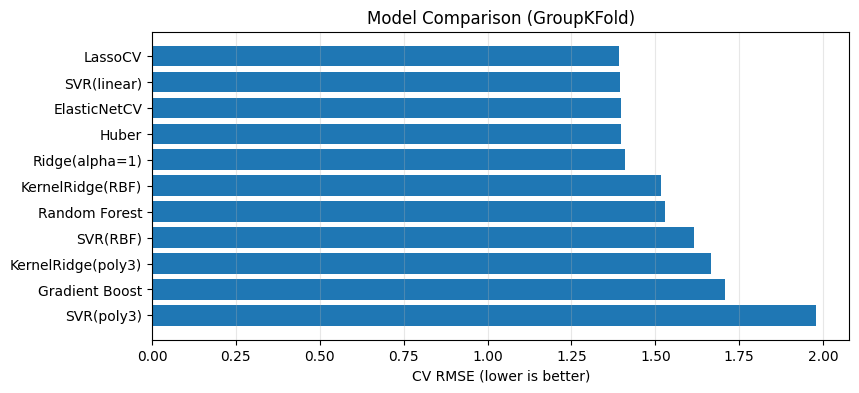

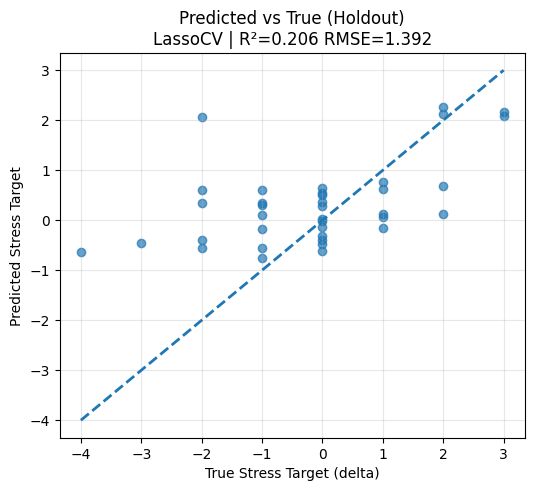

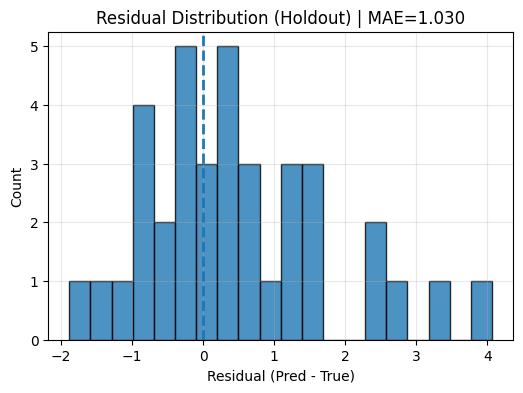


[8] Feature importance (if supported)...

✓ DONE


In [3]:
# I used GroupKFold (
#regularization model (error is minimized ) Kerneling model \
# ================================================================
# IMPROVED STRESS REGRESSION (NUMERIC STRESS SCORE / DELTA STRESS)
# V1 labels for males, V2 labels for females
# Uses existing df_features (preprocessed)
# Fixes female ID mismatch (f01 -> P01), normalizes task strings
# Adds TASK one-hot (big boost)
# Optionally predicts subject-relative stress (delta from baseline) (big boost)
# Optionally within-subject z-score of physiology features (reduces subject bias)
# Uses TRUE group CV (GroupKFold) to avoid subject leakage
# Prints: CV R²/RMSE/MAE + Holdout R²/RMSE/MAE + plots
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge

print("\n" + "="*80)
print("IMPROVED STRESS REGRESSION (GROUP-SAFE)")
print("="*80)

# -----------------------------
# CHOICES (toggle these)
# -----------------------------
USE_TASK_ONEHOT = True               # strongly recommended
USE_GENDER_ONEHOT = False            # optional
PREDICT_DELTA_FROM_BASELINE = True   # recommended (often improves R²)
WITHIN_SUBJECT_ZSCORE = True         # recommended with delta target
MIN_DURATION_SEC = None              # e.g., 30 or 60 if you have 'duration' col
MAX_ROW_MISSING_FRAC = 0.30          # drop rows with >30% missing phys features

# ----------------------------------------------------------------
# 0) NORMALIZATION HELPERS (KEY CLEANING)
# ----------------------------------------------------------------
def norm_subject(s):
    """
    Normalize subject IDs so merges work:
      - 'f01' -> 'P01'
      - 'p1'  -> 'P01'
      - 'S4'  -> 'S04'
    """
    s = str(s).strip()
    if len(s) == 0:
        return s
    low = s.lower()

    if low.startswith("f"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("p"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("s"):
        num = low[1:]
        return "S" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    return s

def norm_task(t):
    """Strip + collapse whitespace so task strings match across sources."""
    return " ".join(str(t).strip().split())

TASK_MAP = {
    # Add mappings only if you discover naming drift:
    # "Transition Rest 1": "Transition Rest",
    # "Transition Rest 2": "Transition Rest",
}
def map_task(t):
    t = norm_task(t)
    return TASK_MAP.get(t, t)

# ----------------------------------------------------------------
# 1) RESHAPE STRESS LABELS (V1 male + V2 female)
#    Requires: stress_level_v1, stress_level_v2 already loaded as DataFrames
# ----------------------------------------------------------------
print("\n[1] Reshaping stress labels (V1 + V2) ...")

stress_male = (
    stress_level_v1.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_male["subject"] = stress_male["subject"].apply(norm_subject)
stress_male["task"] = stress_male["task"].apply(map_task)
stress_male["stress_score"] = pd.to_numeric(stress_male["stress_score"], errors="coerce")
stress_male = stress_male.dropna()

stress_female = (
    stress_level_v2.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_female["subject"] = stress_female["subject"].apply(norm_subject)
stress_female["task"] = stress_female["task"].apply(map_task)
stress_female["stress_score"] = pd.to_numeric(stress_female["stress_score"], errors="coerce")
stress_female = stress_female.dropna()

stress_all = pd.concat([stress_male, stress_female], ignore_index=True)

print(f"Male labels:   {len(stress_male)}")
print(f"Female labels: {len(stress_female)}")
print(f"Total labels:  {len(stress_all)}")
print("Tasks in labels:", sorted(stress_all["task"].unique()))

# ----------------------------------------------------------------
# 2) PREP df_features (normalize merge keys)
# ----------------------------------------------------------------
print("\n[2] Normalizing df_features keys ...")

df_features = df_features.copy()
df_features["subject"] = df_features["subject"].apply(norm_subject)
df_features["task"] = df_features["task"].apply(map_task)

# ----------------------------------------------------------------
# 3) MERGE FEATURES + LABELS
# ----------------------------------------------------------------
print("\n[3] Merging df_features + stress labels ...")

data = df_features.merge(
    stress_all[["subject", "task", "stress_score"]],
    on=["subject", "task"],
    how="inner"
)
print(data)

if len(data) == 0:
    raise ValueError("❌ Merge produced 0 rows. Check subject/task normalization and TASK_MAP.")

print(f"✓ Merged samples: {len(data)}")
print(f"✓ Subjects: {data['subject'].nunique()}")
if "gender" in data.columns:
    print("Merged gender counts:\n", data["gender"].value_counts())

print(f"Stress range: {data['stress_score'].min():.1f} - {data['stress_score'].max():.1f}")
print(f"Stress mean±std: {data['stress_score'].mean():.2f} ± {data['stress_score'].std():.2f}")

# ----------------------------------------------------------------
# 3.5) OPTIONAL FILTERS (duration + missingness)
# ----------------------------------------------------------------
# Duration filter (if you have a 'duration' column)
if MIN_DURATION_SEC is not None and "duration" in data.columns:
    before = len(data)
    data = data[data["duration"] >= MIN_DURATION_SEC].copy()
    print(f"\n[Filter] duration >= {MIN_DURATION_SEC}s: {before} -> {len(data)}")

# ----------------------------------------------------------------
# 4) FEATURE SETUP (base physiological features)
# ----------------------------------------------------------------
print("\n[4] Preparing features ...")

base_feature_cols = [
    "SDNN", 
    "HR_mean", "HR_std", "HR_max",
    "ACC_mean"
]

# keep cols that exist + not mostly missing
base_feature_cols = [c for c in base_feature_cols if c in data.columns and data[c].notna().mean() > 0.5]
if len(base_feature_cols) == 0:
    raise ValueError("❌ No usable base physiological features found in `data`.")

# coerce numeric
data[base_feature_cols] = data[base_feature_cols].apply(pd.to_numeric, errors="coerce")

# Row missingness filter on phys columns
row_missing = data[base_feature_cols].isna().mean(axis=1)
before = len(data)
data = data[row_missing <= MAX_ROW_MISSING_FRAC].copy()
print(f"[Filter] phys missingness <= {MAX_ROW_MISSING_FRAC:.0%}: {before} -> {len(data)}")

# ----------------------------------------------------------------
# 4.5) ADD TASK/GENDER ONE-HOT FEATURES (big boost)
# ----------------------------------------------------------------
dummy_cols = []

if USE_TASK_ONEHOT:
    task_dummies = pd.get_dummies(data["task"], prefix="task")
    data = pd.concat([data, task_dummies], axis=1)
    dummy_cols += task_dummies.columns.tolist()

if USE_GENDER_ONEHOT and "gender" in data.columns:
    gender_dummies = pd.get_dummies(data["gender"], prefix="gender")
    data = pd.concat([data, gender_dummies], axis=1)
    dummy_cols += gender_dummies.columns.tolist()

# ----------------------------------------------------------------
# 4.6) TARGET ENGINEERING (delta from baseline) (big boost)
# ----------------------------------------------------------------
if PREDICT_DELTA_FROM_BASELINE:
    # baseline stress per subject (from Baseline task rows)
    baseline_map = (
        data.loc[data["task"] == "Baseline", ["subject", "stress_score"]]
        .groupby("subject")["stress_score"]
        .mean()
    )

    data["baseline_stress"] = data["subject"].map(baseline_map)

    before = len(data)
    data = data.dropna(subset=["baseline_stress"]).copy()
    print(f"[Target] drop missing baseline: {before} -> {len(data)}")

    data["stress_target"] = data["stress_score"] - data["baseline_stress"]
    print("[Target] Using stress_delta = stress_score - baseline_stress")
else:
    data["stress_target"] = data["stress_score"]
    print("[Target] Using absolute stress_score")

# ----------------------------------------------------------------
# 4.7) WITHIN-SUBJECT Z-SCORE ON PHYS FEATURES (reduces subject bias)
# ----------------------------------------------------------------
if WITHIN_SUBJECT_ZSCORE:
    def zscore(x):
        return (x - x.mean()) / (x.std(ddof=0) + 1e-8)
    data[base_feature_cols] = data.groupby("subject")[base_feature_cols].transform(zscore)
    print("[Features] Applied within-subject z-score to physiology features")

# Final feature set
feature_cols = base_feature_cols + dummy_cols

print(f"✓ Base phys features: {len(base_feature_cols)}")
print(f"✓ Dummy features:     {len(dummy_cols)}")
print(f"✓ Total features:     {len(feature_cols)}")
print("Feature cols (sample):", feature_cols[:10], "..." if len(feature_cols) > 10 else "")

# Build X, y, groups
X = data[feature_cols].apply(pd.to_numeric, errors="coerce").values
y = pd.to_numeric(data["stress_target"], errors="coerce").values
groups = data["subject"].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique subjects: {pd.Series(groups).nunique()}")
print("Target stats:\n", pd.Series(y).describe())

# ----------------------------------------------------------------
# 5) MODELS + GROUP CV (R² / RMSE / MAE)
# ----------------------------------------------------------------
print("\n[5] Training regression models (GroupKFold)...")

models = {
    # Regularized linear baselines
    "Ridge(alpha=1)": Ridge(alpha=1.0),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001),

    # L1 / Elastic Net with built-in CV (no guessing alpha)
    "LassoCV": LassoCV(alphas=np.logspace(-4, 1, 20), max_iter=50000, random_state=42),
    "ElasticNetCV": ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 20),
        max_iter=50000,
        random_state=42
    ),

    # Kernel ridge = “ridge but with kernels” (often strong, smooth fits)
    "KernelRidge(RBF)": KernelRidge(alpha=1.0, kernel="rbf", gamma=0.5),
    "KernelRidge(poly3)": KernelRidge(alpha=1.0, kernel="polynomial", degree=3, gamma=0.1, coef0=1.0),

    # SVR variants (kernel choice)
    "SVR(RBF)": SVR(kernel="rbf", C=10.0, epsilon=0.2, gamma="scale"),
    "SVR(poly3)": SVR(kernel="poly", degree=3, C=10.0, epsilon=0.2, gamma="scale", coef0=1.0),
    "SVR(linear)": SVR(kernel="linear", C=1.0, epsilon=0.2),

    # Trees (nonlinear + interactions)
    "Random Forest": RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42),
    "Gradient Boost": GradientBoostingRegressor(n_estimators=500, max_depth=3, random_state=42),
}


cv = GroupKFold(n_splits=5)

results = []
print("\n5-Fold Group CV:")
print("-" * 100)

for name, model in models.items():
    pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        model
    )

    r2 = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="r2")
    neg_mse = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_squared_error")
    neg_mae = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")

    rmse = float(np.sqrt(-neg_mse.mean()))
    mae = float(-neg_mae.mean())

    results.append({
        "Model": name,
        "CV R2": float(r2.mean()),
        "CV R2 Std": float(r2.std()),
        "CV RMSE": rmse,
        "CV MAE": mae
    })

    print(f"{name:16}: R²={r2.mean():7.3f} (±{r2.std():.3f}) | RMSE={rmse:.3f} | MAE={mae:.3f}")

df_results = pd.DataFrame(results).sort_values("CV RMSE", ascending=True).reset_index(drop=True)

best_name = df_results.loc[0, "Model"]
best_model = models[best_name]
print(f"\n✓ Best by lowest CV RMSE: {best_name}")

# ----------------------------------------------------------------
# 6) GROUP HOLDOUT EVALUATION
# ----------------------------------------------------------------
print("\n[6] Holdout evaluation (GroupShuffleSplit)...")

splitter = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

best_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    best_model
)

best_pipe.fit(X[train_idx], y[train_idx])
y_pred = best_pipe.predict(X[test_idx])

test_r2 = r2_score(y[test_idx], y_pred)
test_rmse = float(np.sqrt(mean_squared_error(y[test_idx], y_pred)))
test_mae = float(mean_absolute_error(y[test_idx], y_pred))

print("\nHoldout metrics:")
print(f"  R²:   {test_r2:.3f}")
print(f"  RMSE: {test_rmse:.3f}")
print(f"  MAE:  {test_mae:.3f}")
print("  Holdout subjects:", sorted(pd.Series(groups[test_idx]).unique()))


# ----------------------------------------------------------------
# 6.5) POST-HOC: MAP REGRESSION OUTPUTS TO Low/Medium/High (INTERPRETATION ONLY)
# ----------------------------------------------------------------
print("\n[6.5] Post-hoc mapping to Low/Medium/High (interpretation only) ...")

# If you are predicting DELTA FROM BASELINE, you must bin DELTA, not absolute stress.
# These thresholds are reasonable starting points; tweak if your delta distribution is different.
def delta_to_level(d):
    if d <= -1:
        return "Low"
    elif d <= 1:
        return "Medium"
    else:
        return "High"

# If you are predicting ABSOLUTE stress_score, bin on the original scale (your earlier choice).
def stress_to_level_abs(s):
    if s <= 3:
        return "Low"
    elif s <= 6:
        return "Medium"
    else:
        return "High"

if PREDICT_DELTA_FROM_BASELINE:
    y_true_level = pd.Series(y[test_idx]).apply(delta_to_level)
    y_pred_level = pd.Series(y_pred).apply(delta_to_level)
    print("Using DELTA bins: Low<=-1, Medium<=1, High>1")
else:
    y_true_level = pd.Series(y[test_idx]).apply(stress_to_level_abs)
    y_pred_level = pd.Series(y_pred).apply(stress_to_level_abs)
    print("Using ABS bins: Low<=3, Medium<=6, High>6")

print("\nTrue levels (holdout):")
print(y_true_level.value_counts())

print("\nPredicted levels (holdout):")
print(y_pred_level.value_counts())

print("\nSample (first 15 holdout predictions):")
preview = pd.DataFrame({
    "subject": pd.Series(groups[test_idx]),
    "task": data.iloc[test_idx]["task"].values if "task" in data.columns else None,
    "y_true": y[test_idx],
    "y_pred": y_pred,
    "true_level": y_true_level.values,
    "pred_level": y_pred_level.values
})
print(preview.head(15))


# ----------------------------------------------------------------
# 7) PLOTS
# ----------------------------------------------------------------
print("\n[7] Creating plots...")

# (A) Model comparison (CV RMSE)
plt.figure(figsize=(9, 4))
plt.barh(df_results["Model"], df_results["CV RMSE"])
plt.xlabel("CV RMSE (lower is better)")
plt.title("Model Comparison (GroupKFold)")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

# (B) Predicted vs True
plt.figure(figsize=(6, 5))
plt.scatter(y[test_idx], y_pred, alpha=0.7)
mn = float(min(y[test_idx].min(), y_pred.min()))
mx = float(max(y[test_idx].max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], "--", linewidth=2)
plt.xlabel("True Stress Target" + (" (delta)" if PREDICT_DELTA_FROM_BASELINE else ""))
plt.ylabel("Predicted Stress Target")
plt.title(f"Predicted vs True (Holdout)\n{best_name} | R²={test_r2:.3f} RMSE={test_rmse:.3f}")
plt.grid(alpha=0.3)
plt.show()

# (C) Residual distribution
residuals = y_pred - y[test_idx]
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("Residual (Pred - True)")
plt.ylabel("Count")
plt.title(f"Residual Distribution (Holdout) | MAE={test_mae:.3f}")
plt.grid(alpha=0.3)
plt.show()

# ----------------------------------------------------------------
# 8) FEATURE IMPORTANCE / COEFS (optional)
# ----------------------------------------------------------------
print("\n[8] Feature importance (if supported)...")

if best_name in ["Ridge", "Huber"]:
    model_step = best_pipe.named_steps[list(best_pipe.named_steps.keys())[-1]]
    # Huber uses coef_ too
    if hasattr(model_step, "coef_"):
        coefs = pd.Series(np.abs(model_step.coef_), index=feature_cols).sort_values(ascending=False)
        print("\nTop coefficients (|coef|):")
        print(coefs.head(15))

        plt.figure(figsize=(8, 4))
        coefs.head(15).sort_values().plot(kind="barh")
        plt.xlabel("|Coefficient|")
        plt.title(f"Top Feature Weights ({best_name})")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

elif best_name in ["Random Forest", "Gradient Boost"]:
    model_step = best_pipe.named_steps[list(best_pipe.named_steps.keys())[-1]]
    if hasattr(model_step, "feature_importances_"):
        imp = pd.Series(model_step.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print("\nTop feature importances:")
        print(imp.head(15))

        plt.figure(figsize=(8, 4))
        imp.head(15).sort_values().plot(kind="barh")
        plt.xlabel("Importance")
        plt.title(f"Top Feature Importances ({best_name})")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

print("\n✓ DONE")

#training & test set separate

